In [356]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [357]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 70
WINDOW_STRIDE_SAMPLES = 10
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [358]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [359]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [360]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [361]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        269628
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64

In [362]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [363]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    31589
696b4743-9d39-4fb1-8271-90e7d48652af    21096
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    39524
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [364]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [365]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

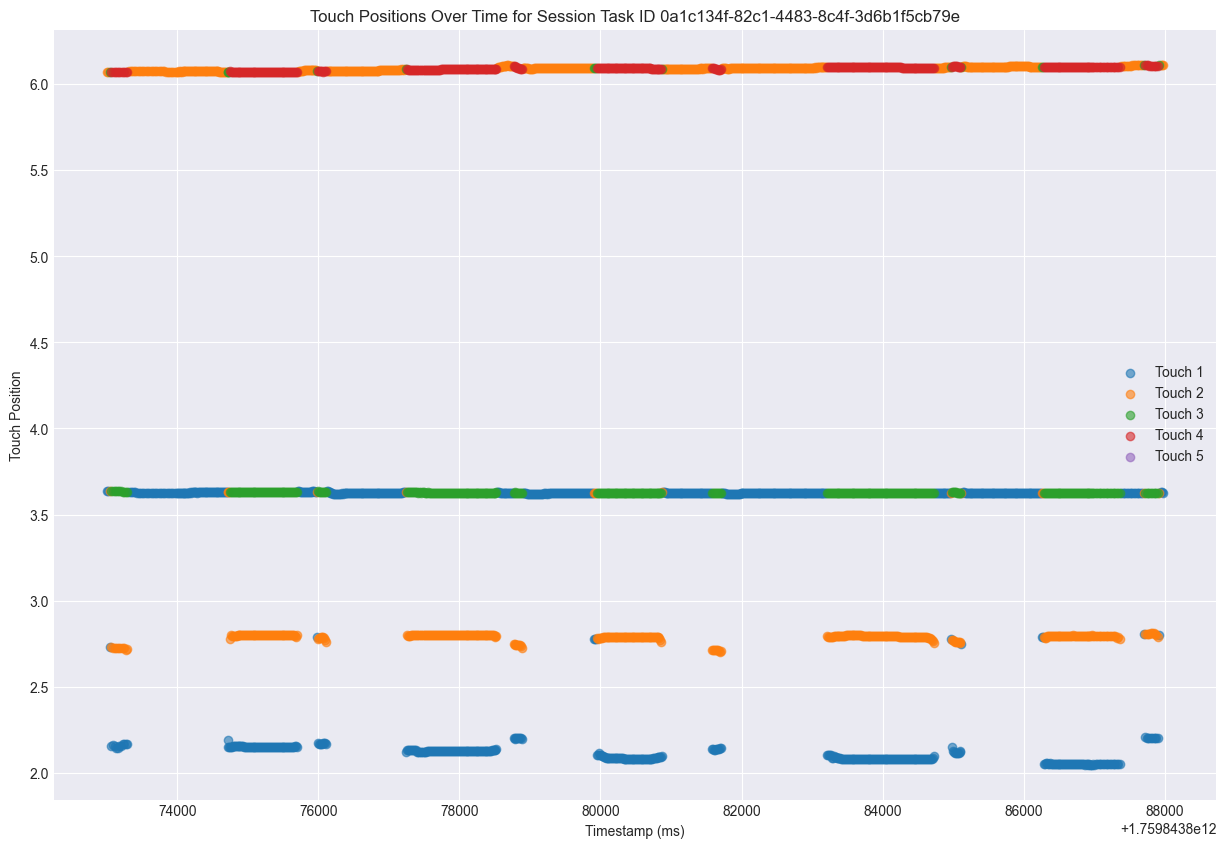

In [366]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [367]:
# Stabilize dataframe
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)
print("Stabilization Complete.")

Stabilization Complete.


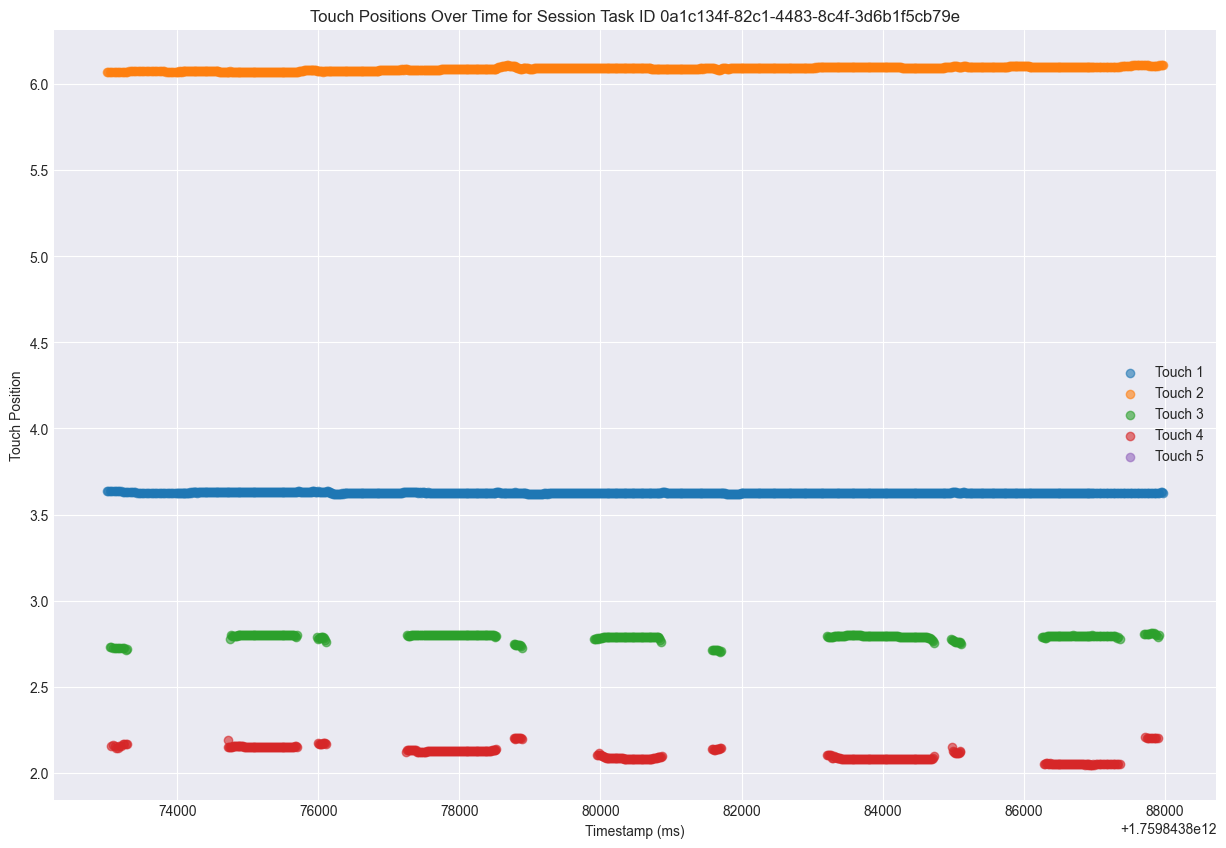

In [368]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [369]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(2, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position    109132
touch_1_pressure    109132
touch_1_channel     109132
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            204519
dtype: int64

In [370]:
# Print the min, max and mean count of samples per group_id
grouped = df_clean.groupby('group_id').size()
print(f"Min samples per group_id: {grouped.min()}")
print(f"Max samples per group_id: {grouped.max()}")
print(f"Mean samples per group_id: {grouped.mean():.2f}")

# Print the parent_gesture for the group_id with the maximum samples
max_group_id = grouped.idxmax()
max_parent_gesture = df_clean[df_clean['group_id'] == max_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with max samples ({max_group_id}): {max_parent_gesture}")

# Print the parent_gesture for the group_id with the minimum samples
min_group_id = grouped.idxmin()
min_parent_gesture = df_clean[df_clean['group_id'] == min_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with min samples ({min_group_id}): {min_parent_gesture}")

# Print the count of samples for the No Gesture parent_gesture that has the max samples
no_gesture_grouped = df_clean[df_clean['parent_gesture'] == 'No Gesture'].groupby('group_id').size()
print(f"Max samples for 'No Gesture' group_id: {no_gesture_grouped.max()}")

Min samples per group_id: 8
Max samples per group_id: 469
Mean samples per group_id: 60.94
Parent gesture for group_id with max samples (262783cc-2cc2-42c8-aa98-25f2500ee1fe): No Gesture
Parent gesture for group_id with min samples (c87bb56f-29e0-4588-bca5-f869084d8315): Two-Finger Tap
Max samples for 'No Gesture' group_id: 469


In [371]:
# Per gesture, print the min and max size of groups
gesture_grouped = df_clean.groupby(['parent_gesture', 'group_id']).size().reset_index(name='size')
for gesture, group in gesture_grouped.groupby('parent_gesture'):
    min_non_zero_size = group[group['size'] > 0]['size'].min()
    max_size = group['size'].max()
    print(f"Gesture: {gesture}, Min samples in group: {min_non_zero_size}, Max samples in group: {max_size}")

Gesture: Double Tap, Min samples in group: 20, Max samples in group: 42
Gesture: No Gesture, Min samples in group: 9, Max samples in group: 469
Gesture: Single Tap, Min samples in group: 9, Max samples in group: 24
Gesture: Two-Finger Double Tap, Min samples in group: 22, Max samples in group: 55
Gesture: Two-Finger Opposite Double Tap, Min samples in group: 21, Max samples in group: 49
Gesture: Two-Finger Opposite Tap, Min samples in group: 9, Max samples in group: 28
Gesture: Two-Finger Tap, Min samples in group: 8, Max samples in group: 47


In [372]:
WINDOW_GESTURE_MAJORITY_THRESHOLD = 1 / grouped.min()
print(WINDOW_GESTURE_MAJORITY_THRESHOLD)

0.125


In [373]:
# Create sliding windows from the cleaned DataFrame
X_windows = []
y_windows = []
meta_data = []

# did_print = 0

print("Creating sliding windows...")
for (session_task_id, participant_id), group in df_clean.groupby(['session_task_id', 'participant_id']):
    sensor_data = group[SENSOR_COLUMNS].values
    labels = group[LABEL_COLUMN].values
    is_gesture = group['is_gesture'].values

    # Does any of the gestures in this group end with a "Tap"
    includesATapGesture = np.any(is_gesture == 1)
    
    num_samples = sensor_data.shape[0]
    for start in range(0, num_samples - WINDOW_SIZE_SAMPLES + 1, WINDOW_STRIDE_SAMPLES):
        # if includesATapGesture:
        #     did_print += 1

        end = start + WINDOW_SIZE_SAMPLES
        window_data = sensor_data[start:end]
        window_labels = labels[start:end]

        majority_label = "No Gesture"
        # If there is a a gesture fully shown in this window (meaning there is is_gesture == 0, is_gesture == 1 and is_gesture == 0 again)
        gesture_indices = np.where(is_gesture[start:end] == 1)[0]
        if len(gesture_indices) > 0:
            first_gesture_index = gesture_indices[0]
            last_gesture_index = gesture_indices[-1]
            if first_gesture_index > 0 and last_gesture_index < WINDOW_SIZE_SAMPLES - 1:
                majority_label = window_labels[first_gesture_index]
        # else:
        #     # Otherwise, use majority voting if above threshold
        #     label_counts = pd.Series(window_labels).value_counts(normalize=True)
        #     top_label = label_counts.idxmax()
        #     top_label_ratio = label_counts.max()
        #     if top_label_ratio >= WINDOW_GESTURE_MAJORITY_THRESHOLD and top_label != 'No Gesture':
        #         majority_label = top_label

        # if did_print < 20 and majority_label != 'No Gesture' and includesATapGesture:
        #     # Draw a graph of all touch positions for this session_task_id
        #     plt.figure(figsize=(15, 10))
        #     for touch_num in range(1, 6):
        #         plt.scatter(
        #             group["timestamp_ms"].values[start:end],
        #             group[f"touch_{touch_num}_position"].values[start:end],
        #             label=f"Touch {touch_num}", 
        #             alpha=0.6
        #         )
        #     plt.xlabel("Timestamp (ms)")
        #     plt.ylabel("Touch Position")
        #     plt.title(f"Touch Positions Over Time for Session Task ID {session_task_id} with majority label '{majority_label}'")
        #     plt.legend()
        #     plt.show() 

        if majority_label == 'No Gesture':
            continue
        
        X_windows.append(window_data)
        y_windows.append(majority_label)
        meta_data.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end,
        })
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
meta_data_df = pd.DataFrame(meta_data)
print(f"Created {X_windows.shape[0]} windows of size {WINDOW_SIZE_SAMPLES} samples.")
# Display the shape of the created windows
X_windows.shape, y_windows.shape, meta_data_df.shape


Creating sliding windows...
Created 1920 windows of size 70 samples.


((1920, 70, 17), (1920,), (1920, 4))

In [374]:
# Print the value counts of the labels in the windows
unique, counts = np.unique(y_windows, return_counts=True)
label_counts = dict(zip(unique, counts))
print("Window Label Counts:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Window Label Counts:
Double Tap: 286
Single Tap: 373
Two-Finger Double Tap: 248
Two-Finger Opposite Double Tap: 253
Two-Finger Opposite Tap: 356
Two-Finger Tap: 404


In [375]:
def extract_features(window, is_padded_window):
    features = []
    feature_names = [] # for debug purposes we store the names of each feature at the same index
    
    # Assume sensor column order from SENSOR_COLUMNS
    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_channel_cols = [4, 7, 10, 13, 16]  # touch_X_channel indices
    touch_pressure_cols = [3, 6, 9, 12, 15]  # touch_X_pressure indices
    touch_position_cols = [2, 5, 8, 11, 14]  # touch_X_position indices
    original_length_col = len(SENSOR_COLUMNS)  # last column is original length

    button_press_data = window[:, button_col]
    motor_data = window[:, motor_col]
    touch_pressures = window[:, touch_pressure_cols]
    touch_positions = window[:, touch_position_cols]
    # Only consider touch positions where the pressure > 0
    valid_mask = touch_pressures > 0
    touch_positions = touch_positions[valid_mask]
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    # A 1 signalizes the button was pressed, this can happen multiple times in a window, so we first have to extract each consecutive time a button was pressed, plus the amount of samples for each time
    binary_button_press = (button_press_data > 0).astype(int)
    padded_button_press = np.concatenate(([0], binary_button_press, [0]))
    button_press_diff = np.diff(padded_button_press)
    button_press_starts = np.where(button_press_diff == 1)[0]
    button_press_ends = np.where(button_press_diff == -1)[0]
    button_press_durations = button_press_ends - button_press_starts

    def circular_range(angles):
        # 1. Sort the angles
        sorted_angles = np.sort(angles)
        # 2. Calculate gaps between neighbors
        gaps = np.diff(sorted_angles)
        # 3. Calculate the wrap-around gap (last to first)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        # 4. Combine all gaps
        all_gaps = np.append(gaps, wrap_gap)
        # 5. Range is the full circle minus the biggest empty space
        return 2 * np.pi - np.max(all_gaps)
    
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # Button Features
    # 1. Button pressed at all?
    # add_feature("button_pressed_any", np.any(binary_button_press))
    # # 2. How often was the button pressed (changed from 0 to 1 and vice versa) and how often was it let go
    # add_feature("button_press_count", len(button_press_starts))
    # # 3. Mean (raw + durations)
    # add_feature("button_press_mean", np.mean(binary_button_press))
    # add_feature("button_press_duration_mean", np.mean(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 4. Std Dev (raw + durations)
    # add_feature("button_press_std", np.std(binary_button_press))
    # add_feature("button_press_duration_std", np.std(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 5. Median (raw + durations)
    # add_feature("button_press_median", np.median(binary_button_press))
    # add_feature("button_press_duration_median", np.median(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 6. Max duration
    # add_feature("button_press_max_duration", np.max(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 7. Min duration
    # add_feature("button_press_min_duration", np.min(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 8. Range duration
    # add_feature("button_press_range_duration", circular_range(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 9. Total duration
    # add_feature("button_press_total_duration", np.sum(button_press_durations) if len(button_press_durations) > 0 else 0)

    # Motor Angle Features
    # 1. Mean
    # add_feature("motor_angle_mean", np.mean(motor_data))
    # # 2. Std Dev
    # add_feature("motor_angle_std", np.std(motor_data))
    # # 3. Min Max
    # add_feature("motor_angle_min", np.min(motor_data))
    # add_feature("motor_angle_max", np.max(motor_data))
    # # 4. Range
    # add_feature("motor_angle_range", circular_range(motor_data))
    # # 5. Median
    # add_feature("motor_angle_median", np.median(motor_data))
    # # 6. Q25 / Q75
    # add_feature("motor_angle_q25", np.percentile(motor_data, 25))
    # add_feature("motor_angle_q75", np.percentile(motor_data, 75))
    # # 7. Skewness / Kurtosis
    # add_feature("motor_angle_skewness", stats.skew(motor_data))
    # add_feature("motor_angle_kurtosis", stats.kurtosis(motor_data))
    # # 8. Velocity
    # if len(motor_data) > 1:
        # motor_velocity = np.diff(motor_data) * SAMPLING_RATE_HZ
        # add_feature("motor_velocity_mean", np.mean(motor_velocity))
        # add_feature("motor_velocity_std", np.std(motor_velocity))
        # add_feature("motor_velocity_max", np.max(motor_velocity))
    # else:
        # add_feature("motor_velocity_mean", 0)
        # add_feature("motor_velocity_std", 0)
        # add_feature("motor_velocity_max", 0)

    # General Touch Activity Features
    # 1. Max simultaneous touches
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    # 2. Avg active touches
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    # 3. Any touch at all?
    add_feature("any_touch", np.any(active_touches))
    # 4. Total pressure across all sensors
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    # 5. Max pressure
    add_feature("max_pressure", np.max(touch_pressures))
    # 5.1 Min non-zero pressure
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)
    # 6. Touch centroid
    touch_position_sin_mean = np.sin(touch_positions).mean()
    touch_position_cos_mean = np.cos(touch_positions).mean()
    touch_position_mean_angle = np.arctan2(touch_position_sin_mean, touch_position_cos_mean)
    add_feature("touch_centroid", touch_position_mean_angle % (2 * np.pi))
    # 7. Touch Spread
    touch_position_R = np.sqrt(touch_position_sin_mean**2 + touch_position_cos_mean**2)
    add_feature("touch_spread", 1 - touch_position_R)
    add_feature("touch_spread_log", -np.log(np.clip(touch_position_R, 1e-9, 1.0)))

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    i = 0
    for p1, p2 in combinations(touch_position_cols, 2):
        i += 1
        finger1_positions = window[:, p1]
        finger2_positions = window[:, p2]
        # Only consider positions where the pressure > 0
        finger1_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p1)]]
        finger2_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p2)]]
        valid_mask = (finger1_pressures > 0) & (finger2_pressures > 0)
        finger1_positions = finger1_positions[valid_mask]
        finger2_positions = finger2_positions[valid_mask]

        distances = short_dist(finger1_positions, finger2_positions)

        # Calculate the distance values in 5 buckets to get a better temporal understanding of what is happening at the start middle and end
        buckets = np.array_split(distances, 5)
        for b_idx, bucket in enumerate(buckets):
            has_distance = len(bucket) != 0
            add_feature(f"finger_distance_{i}_mean_bucket_{b_idx+1}", np.mean(bucket) if has_distance else 0)
            add_feature(f"finger_distance_{i}_std_bucket_{b_idx+1}", np.std(bucket) if has_distance else 0)
            add_feature(f"finger_distance_{i}_max_bucket_{b_idx+1}", np.max(bucket) if has_distance else 0)
            add_feature(f"finger_distance_{i}_min_bucket_{b_idx+1}", np.min(bucket) if has_distance else 0)
            add_feature(f"finger_distance_{i}_range_bucket_{b_idx+1}", circular_range(bucket) if has_distance else 0)
            add_feature(f"finger_distance_{i}_q25_bucket_{b_idx+1}", np.percentile(bucket, 25) if has_distance else 0)
            add_feature(f"finger_distance_{i}_q75_bucket_{b_idx+1}", np.percentile(bucket, 75) if has_distance else 0)

        # If the distances are empty add 0 for all
        has_distance = len(distances) != 0
        add_feature(f"finger_distance_{i}_mean", np.mean(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_std", np.std(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_max", np.max(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_min", np.min(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_range", circular_range(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_q25", np.percentile(distances, 25) if has_distance else 0)
        add_feature(f"finger_distance_{i}_q75", np.percentile(distances, 75) if has_distance else 0)


    amount_active_moving_fingers = 0
    # Per Finger Features
    for i, (pos_col, press_col, channel_col) in enumerate(zip(touch_position_cols, touch_pressure_cols, touch_channel_cols)):
        finger_positions = window[:, pos_col]
        finger_pressures = window[:, press_col]
        finger_channels = window[:, channel_col]

        # Fill nan with 0
        finger_positions = np.nan_to_num(finger_positions, nan=0.0)
        finger_pressures = np.nan_to_num(finger_pressures, nan=0.0)

        # Only consider positions where the pressure > 0
        valid_mask = finger_pressures > 0
        finger_positions = finger_positions[valid_mask]
        finger_channels = finger_channels[valid_mask]

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # Create 5 moved buckets
        moved_buckets = np.array_split(finger_positions, 5)
        for b_idx, bucket in enumerate(moved_buckets):
            bucket_range = circular_range(bucket) if len(bucket) > 0 else 0
            add_feature(f"finger_{i+1}_moved_range_bucket_{b_idx+1}", bucket_range)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Get the time between reactivations
        touch_reactivation_times = []
        last_touch_end = None
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                if last_touch_end is not None:
                    touch_reactivation_times.append(t - last_touch_end)
            if not is_touching[t] and is_touching[t - 1]:
                last_touch_end = t
        # Mean time between reactivations
        add_feature(f"finger_{i+1}_mean_time_between_reactivations", np.mean(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Std Dev time between reactivations
        add_feature(f"finger_{i+1}_std_time_between_reactivations", np.std(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Max time between reactivations
        add_feature(f"finger_{i+1}_max_time_between_reactivations", np.max(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Min time between reactivations
        add_feature(f"finger_{i+1}_min_time_between_reactivations", np.min(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Range time between reactivations
        add_feature(f"finger_{i+1}_range_time_between_reactivations", np.abs(np.max(touch_reactivation_times) - np.min(touch_reactivation_times)) if len(touch_reactivation_times) > 0 else 0)

        # Create 5 reactivation buckets to get a better temporal understanding of what is happening at the start middle and end
        reactivation_buckets = np.array_split(touch_reactivation_times, 5)
        for b_idx, bucket in enumerate(reactivation_buckets):
            has_reactivation = len(bucket) != 0
            add_feature(f"finger_{i+1}_mean_time_between_reactivations_bucket_{b_idx+1}", np.mean(bucket) if has_reactivation else 0)
            add_feature(f"finger_{i+1}_std_time_between_reactivations_bucket_{b_idx+1}", np.std(bucket) if has_reactivation else 0)
            add_feature(f"finger_{i+1}_max_time_between_reactivations_bucket_{b_idx+1}", np.max(bucket) if has_reactivation else 0)
            add_feature(f"finger_{i+1}_min_time_between_reactivations_bucket_{b_idx+1}", np.min(bucket) if has_reactivation else 0)
            add_feature(f"finger_{i+1}_range_time_between_reactivations_bucket_{b_idx+1}", np.abs(np.max(bucket) - np.min(bucket)) if has_reactivation else 0)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Create 5 duration buckets to get a better temporal understanding of what is happening at the start middle and end
        duration_buckets = np.array_split(touch_durations, 5)
        for b_idx, bucket in enumerate(duration_buckets):
            has_duration = len(bucket) != 0
            add_feature(f"finger_{i+1}_mean_touch_duration_bucket_{b_idx+1}", np.mean(bucket) if has_duration else 0)
            add_feature(f"finger_{i+1}_std_touch_duration_bucket_{b_idx+1}", np.std(bucket) if has_duration else 0)
            add_feature(f"finger_{i+1}_max_touch_duration_bucket_{b_idx+1}", np.max(bucket) if has_duration else 0)
            add_feature(f"finger_{i+1}_min_touch_duration_bucket_{b_idx+1}", np.min(bucket) if has_duration else 0)
            add_feature(f"finger_{i+1}_range_touch_duration_bucket_{b_idx+1}", np.abs(np.max(bucket) - np.min(bucket)) if has_duration else 0)
            add_feature(f"finger_{i+1}_total_touch_duration_bucket_{b_idx+1}", np.sum(bucket) if has_duration else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)
            # 8. Skewness / Kurtosis
            add_feature(f"finger_{i+1}_{data_type}_skewness", stats.skew(data) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_kurtosis", stats.kurtosis(data) if has_data else 0)
            if data_type == "channels":
                continue
            # 9. Velocity
            has_velocity = len(data) > 1
            pressure_velocity = np.diff(data) * SAMPLING_RATE_HZ
            add_feature(f"finger_{i+1}_{data_type}_velocity_mean", np.mean(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_std", np.std(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_max", np.max(pressure_velocity) if has_velocity else 0)
            if data_type == "pressures":
                continue
            # 10. Acceleration
            has_acceleration = len(data) > 2
            pressure_acceleration = np.diff(data, n=2) * (SAMPLING_RATE_HZ ** 2)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_mean", np.mean(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_std", np.std(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_max", np.max(pressure_acceleration) if has_acceleration else 0)

            # Create 5 buckets to get a better temporal understanding of what is happening at the start middle and end
            buckets = np.array_split(data, 5)
            for b_idx, bucket in enumerate(buckets):
                has_bucket_data = len(bucket) != 0
                add_feature(f"finger_{i+1}_{data_type}_mean_bucket_{b_idx+1}", np.mean(bucket) if has_bucket_data else 0)
                add_feature(f"finger_{i+1}_{data_type}_std_bucket_{b_idx+1}", np.std(bucket) if has_bucket_data else 0)
                add_feature(f"finger_{i+1}_{data_type}_max_bucket_{b_idx+1}", np.max(bucket) if has_bucket_data else 0)
                add_feature(f"finger_{i+1}_{data_type}_min_bucket_{b_idx+1}", np.min(bucket) if has_bucket_data else 0)
                add_feature(f"finger_{i+1}_{data_type}_range_bucket_{b_idx+1}", circular_range(bucket) if has_bucket_data else 0)
                add_feature(f"finger_{i+1}_{data_type}_q25_bucket_{b_idx+1}", np.percentile(bucket, 25) if has_bucket_data else 0)
                add_feature(f"finger_{i+1}_{data_type}_q75_bucket_{b_idx+1}", np.percentile(bucket, 75) if has_bucket_data else 0)

    # 8. Amount of fingers minus the amount of fingers that are constantly touching and not moving
    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [376]:
le = LabelEncoder()
y_windows_encoded = le.fit_transform(y_windows)

In [377]:
# Print nan for both datasets before feature extraction
print(f"NaN in windows before feature extraction: {np.isnan(X_windows).any()}")

NaN in windows before feature extraction: True


In [378]:
feature_names = extract_features(X_windows[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_windows_extracted = np.array([extract_features(win, False)[0] for win in X_windows], dtype=np.float32)
print(f"Extracted features shape: {X_windows_extracted.shape}")  # should be (N_windows, N_features)

Extracted features shape: (1920, 1206)


In [379]:
# Print nan for both datasets after feature extraction
print(f"NaN in windows after feature extraction: {np.isnan(X_windows_extracted).any()}")

NaN in windows after feature extraction: True


In [380]:
# Set all nan values to 0
X_win = np.nan_to_num(X_windows_extracted, nan=0.0)

In [381]:
# Lets visualize the X_sequences for the "Double Tap" gesture
gesture_name = "Two-Finger Double Tap"
print("Values for gesture:", gesture_name)
gesture_index = np.where(le.classes_ == gesture_name)[0][0]
indices = np.where(y_windows_encoded == gesture_index)[0]
if len(indices) == 0:
    print(f"No samples found for gesture: {gesture_name}")
else:
    sample_index = indices[0]
    sample_features = X_win[sample_index]

    # Print the values with the feature name for this row
    for fname, fvalue in zip(feature_names, sample_features):
        print(f"{fname}: {fvalue}")

Values for gesture: Two-Finger Double Tap
max_simultaneous_touches: 3.0
avg_active_touches: 2.3428571224212646
any_touch: 1.0
total_active_touch_samples: 164.0
total_pressure: 147455.0
max_pressure: 1066.0
min_non_zero_pressure: 45.0
touch_centroid: 2.645155429840088
touch_spread: 0.7438278794288635
touch_spread_log: 1.361905813217163
finger_distance_1_mean_bucket_1: 2.335373878479004
finger_distance_1_std_bucket_1: 0.001071297563612461
finger_distance_1_max_bucket_1: 2.3372297286987305
finger_distance_1_min_bucket_1: 2.334001302719116
finger_distance_1_range_bucket_1: 0.003228604793548584
finger_distance_1_q25_bucket_1: 2.334552764892578
finger_distance_1_q75_bucket_1: 2.335906744003296
finger_distance_1_mean_bucket_2: 2.337409734725952
finger_distance_1_std_bucket_2: 0.0008338011102750897
finger_distance_1_max_bucket_2: 2.338320732116699
finger_distance_1_min_bucket_2: 2.3358983993530273
finger_distance_1_range_bucket_2: 0.0024222135543823242
finger_distance_1_q25_bucket_2: 2.3366789

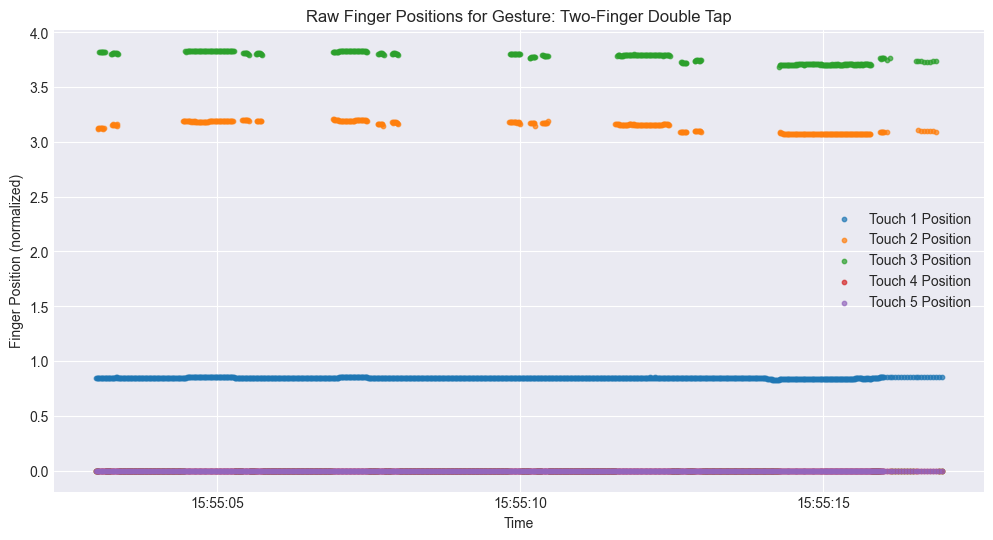

In [382]:
# Draw a graph of the raw finger position data for the same sample
raw_sample = df_clean[
    df_clean["session_task_id"] == meta_data_df.iloc[indices[0]]["session_task_id"]
]

plt.figure(figsize=(12, 6))

for i in range(5):
    pos_col = f'touch_{i+1}_position'
    plt.scatter(
        raw_sample['estimated_timestamp'],
        raw_sample[pos_col],
        s=10,        # point size
        alpha=0.7,   # transparency to reduce overplotting
        label=f'Touch {i+1} Position'
    )

plt.xlabel('Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Raw Finger Positions for Gesture: {gesture_name}')
plt.legend()
plt.show()

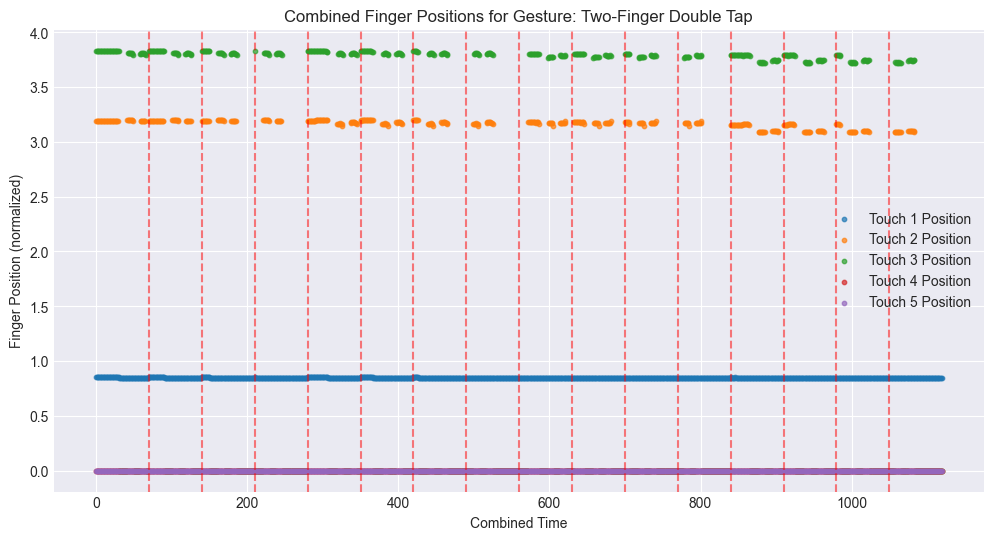

In [383]:
# Draw a graph of the finger positions for all windows that was classified as the gesture, as if they where performed right after one another, with vertical colored lines indicating the window boundaries
plt.figure(figsize=(12, 6))

indices_checked = set()
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    combined_positions = []

    for idx in indices:
        window_start = meta_data_df.iloc[idx]['start_index']
        window_end = meta_data_df.iloc[idx]['end_index']
        session_id = meta_data_df.iloc[idx]['session_task_id']

        # continue if the session_task_id is not in raw_sample
        if session_id not in raw_sample['session_task_id'].values:
            continue

        # add to indices checekd
        indices_checked.add(idx)

        window_data = df_clean[
            df_clean['session_task_id'] == session_id
        ].iloc[window_start:window_end]

        combined_positions.extend(window_data[pos_col].values)

    combined_positions = np.array(combined_positions)
    x = np.arange(len(combined_positions))

    plt.scatter(
        x,
        combined_positions,
        s=10,              # marker size (adjust as needed)
        alpha=0.7,
        label=f'Touch {i+1} Position'
    )

plt.xlabel('Combined Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Combined Finger Positions for Gesture: {gesture_name}')

# Draw vertical lines for window boundaries
for w in range(1, len(indices_checked)):
    plt.axvline(
        x=w * WINDOW_SIZE_SAMPLES,
        color='red',
        linestyle='--',
        alpha=0.5
    )

plt.legend()
plt.show()

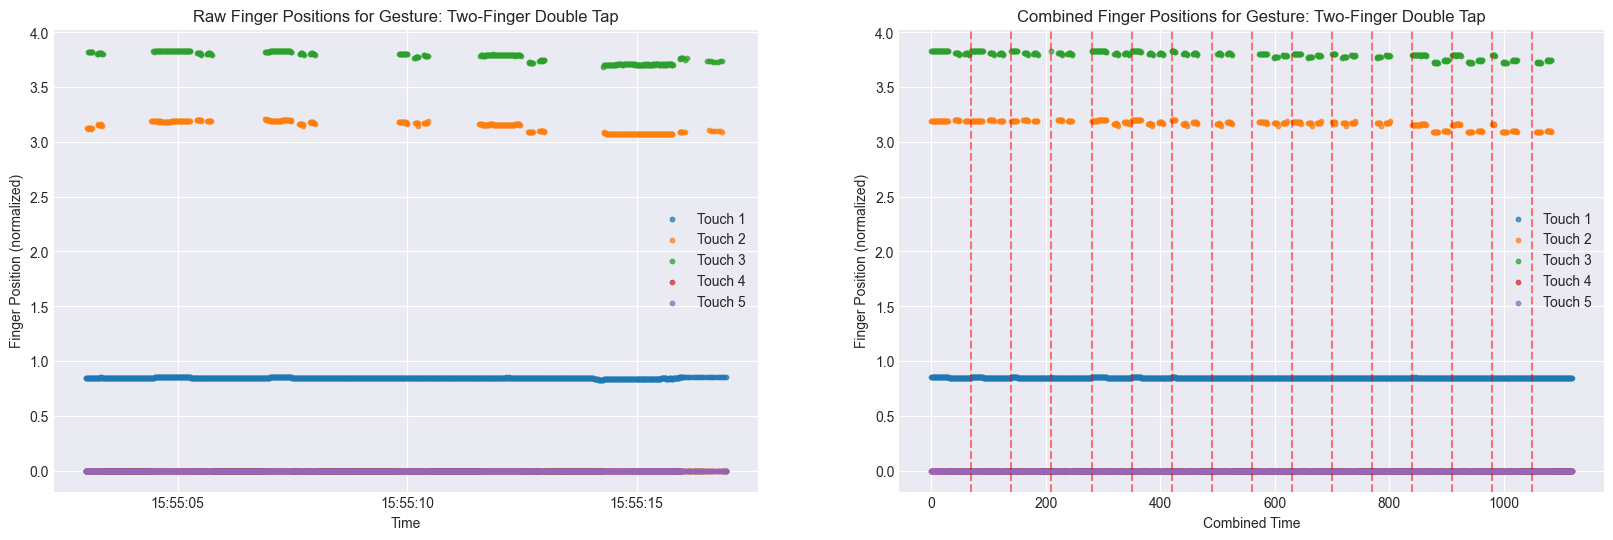

In [384]:
# draw the two graphs side by side
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
# Left graph: Raw finger positions
axs[0].set_title(f'Raw Finger Positions for Gesture: {gesture_name}')
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    axs[0].scatter(
        raw_sample['estimated_timestamp'],
        raw_sample[pos_col],
        s=10,        # point size
        alpha=0.7,   # transparency to reduce overplotting
        label=f'Touch {i+1}'
    )
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Finger Position (normalized)')
axs[0].legend()
# Right graph: Combined finger positions
axs[1].set_title(f'Combined Finger Positions for Gesture: {gesture_name}')
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    combined_positions = []

    for idx in indices:
        window_start = meta_data_df.iloc[idx]['start_index']
        window_end = meta_data_df.iloc[idx]['end_index']
        session_id = meta_data_df.iloc[idx]['session_task_id']

        # continue if the session_task_id is not in raw_sample
        if session_id not in raw_sample['session_task_id'].values:
            continue

        window_data = df_clean[
            df_clean['session_task_id'] == session_id
        ].iloc[window_start:window_end]

        combined_positions.extend(window_data[pos_col].values)

    combined_positions = np.array(combined_positions)
    x = np.arange(len(combined_positions))

    axs[1].scatter(
        x,
        combined_positions,
        s=10,              # marker size (adjust as needed)
        alpha=0.7,
        label=f'Touch {i+1}'
    )
axs[1].set_xlabel('Combined Time')
axs[1].set_ylabel('Finger Position (normalized)')
# Draw vertical lines for window boundaries
for w in range(1, len(indices_checked)):
    axs[1].axvline(
        x=w * WINDOW_SIZE_SAMPLES,
        color='red',
        linestyle='--',
        alpha=0.5
    )
axs[1].legend()
plt.show()

In [385]:
participant_ids = meta_data_df['participant_id'].unique().tolist()
amount_of_participants = len(participant_ids)

train_pids = participant_ids[:amount_of_participants - 2]
val_pids = participant_ids[amount_of_participants - 2:amount_of_participants - 1]
test_pids = participant_ids[amount_of_participants - 1:]

print(f"Amount of participants: {amount_of_participants} (Train: {len(train_pids)}, Val: {len(val_pids)}, Test: {len(test_pids)})")

Amount of participants: 8 (Train: 6, Val: 1, Test: 1)


In [386]:
# Split sliding windows
train_mask_win = meta_data_df['participant_id'].isin(train_pids)
X_train_win = X_win[train_mask_win]
y_train_win = y_windows_encoded[train_mask_win]

val_mask_win = meta_data_df['participant_id'].isin(val_pids)
X_val_win = X_win[val_mask_win]
y_val_win = y_windows_encoded[val_mask_win]

test_mask_win = meta_data_df['participant_id'].isin(test_pids)
X_test_win = X_win[test_mask_win]
y_test_win = y_windows_encoded[test_mask_win]

In [387]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train_win == label_int)
    val_count = np.sum(y_val_win == label_int)
    test_count = np.sum(y_test_win == label_int)
    print(f"Label: {label} | Train: {train_count} | Val: {val_count} | Test: {test_count}")

Label: Double Tap | Train: 223 | Val: 29 | Test: 34
Label: Single Tap | Train: 281 | Val: 42 | Test: 50
Label: Two-Finger Double Tap | Train: 205 | Val: 6 | Test: 37
Label: Two-Finger Opposite Double Tap | Train: 202 | Val: 24 | Test: 27
Label: Two-Finger Opposite Tap | Train: 269 | Val: 47 | Test: 40
Label: Two-Finger Tap | Train: 321 | Val: 40 | Test: 43


In [388]:
# Print train / val / test shapes for windows for both full and windowed
print(f"Sliding Window Split:")
print(f"  X_train_win: {X_train_win.shape}, y_train_win: {y_train_win.shape}")
print(f"  X_val_win:   {X_val_win.shape},   y_val_win:   {y_val_win.shape}")
print(f"  X_test_win:  {X_test_win.shape},  y_test_win:  {y_test_win.shape}")

Sliding Window Split:
  X_train_win: (1501, 1206), y_train_win: (1501,)
  X_val_win:   (188, 1206),   y_val_win:   (188,)
  X_test_win:  (231, 1206),  y_test_win:  (231,)


In [389]:
# Scale both datasets
scaler = StandardScaler()
X_train_win = scaler.fit_transform(X_train_win)
X_val_win = scaler.transform(X_val_win)
X_test_win = scaler.transform(X_test_win)

In [390]:
# CV Training
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.svm import LinearSVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.naive_bayes import GaussianNB

# MODEL_CONFIGS = [
#     {
#         "name": "RandomForest",
#         "pipeline": Pipeline([
#             ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
#         ]),
#         "param_grid": {
#             "clf__n_estimators":      [50, 200, 400, 800],
#             "clf__max_depth":         [None, 10, 20, 30],
#             "clf__min_samples_split": [2, 5, 10],
#             "clf__min_samples_leaf":  [1, 2, 4],
#             "clf__max_features":      ["sqrt", "log2", 0.5],
#             "clf__class_weight":      [None, "balanced"],
#         },
#     },
#     {
#         "name": "KNN",
#         "pipeline": Pipeline([
#             ("scaler", StandardScaler()),
#             ("clf", KNeighborsClassifier())
#         ]),
#         "param_grid": {
#             "clf__n_neighbors": [3, 5, 9],
#             "clf__weights": ["uniform", "distance"],
#             "clf__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
#         },
#     },
#     {
#         "name": "ExtraTrees",
#         "pipeline": Pipeline([
#             ("clf", ExtraTreesClassifier(random_state=42, n_jobs=-1))
#         ]),
#         "param_grid": {
#             "clf__n_estimators":      [50, 200, 400, 800],
#             "clf__max_depth":         [None, 10, 20, 30],
#             "clf__min_samples_split": [2, 5, 10],
#             "clf__min_samples_leaf":  [1, 2, 4],
#             "clf__max_features":      ["sqrt", "log2", 0.5],
#             "clf__class_weight":      [None, "balanced"],
#         },
#     },
#     {
#         "name": "LinearSVC",
#         "pipeline": Pipeline([
#             ("scaler", StandardScaler()),
#             ("clf", LinearSVC(
#                 max_iter=5000,
#                 dual=False
#             ))
#         ]),
#         "param_grid": {
#             "clf__C": [0.1, 1.0, 10.0],
#             "clf__class_weight": [None, "balanced"],
#         },
#     },
#     {
#         "name": "AdaBoost",
#         "pipeline": Pipeline([
#             ("clf", AdaBoostClassifier(random_state=42))
#         ]),
#         "param_grid": {
#             "clf__n_estimators": [50, 100, 200],
#             "clf__learning_rate": [0.01, 0.1, 1.0],
#         },
#     },
#     {
#         "name": "GaussianNB",
#         "pipeline": Pipeline([
#             ("scaler", StandardScaler()),
#             ("clf", GaussianNB())
#         ]),
#         "param_grid": {
#             # No hyperparameters to tune for GaussianNB
#         },
#     }
# ]


In [391]:
# CV Training
# from sklearn.model_selection import GroupKFold, GridSearchCV

# SCORING = "f1_macro"
# gkf = GroupKFold(n_splits=amount_of_participants-2)
# groups_train = meta_data_df[train_mask_win]["participant_id"].values

# best_model = None
# best_model_name = None
# best_score = -np.inf
# all_results = []

# for cfg in MODEL_CONFIGS:
#     name = cfg["name"]
#     pipe = cfg["pipeline"]
#     param_grid = cfg["param_grid"]

#     print(f"\n=== Tuning {name} ===")
#     grid = GridSearchCV(
#         estimator=pipe,
#         param_grid=param_grid,
#         cv=gkf,
#         scoring=SCORING,
#         n_jobs=-1,
#         verbose=2
#     )
#     grid.fit(X_train_win, y_train_win, groups=groups_train)

#     print(f"{name} best params: {grid.best_params_}")
#     print(f"{name} best CV {SCORING}: {grid.best_score_:.4f}")

#     all_results.append({
#         "model": name,
#         "best_score": grid.best_score_,
#         "best_params": grid.best_params_,
#         "estimator": grid.best_estimator_,
#     })

#     if grid.best_score_ > best_score:
#         best_score = grid.best_score_
#         best_model = grid.best_estimator_
#         best_model_name = name

# print("\n=== Summary over all models ===")
# for res in all_results:
#     print(f"{res['model']}: {SCORING}={res['best_score']:.4f}")

# print(f"\nBest overall model: {best_model_name} with {SCORING}={best_score:.4f}")


In [392]:
# Random Training
from scipy.stats import randint, uniform, loguniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

MODEL_CONFIGS = [
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800), # Sample any integer between 50-800
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    },
    {
        "name": "KNN",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": randint(3, 15),
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],
        },
    },
    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800),
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    }
]

In [393]:
# Random Training
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

SCORING = "f1_macro"
gkf = GroupKFold(n_splits=amount_of_participants-2)
groups_train = meta_data_df[train_mask_win]["participant_id"].values

best_model = None
best_model_name = None
best_score = -np.inf
all_results = []

for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]
    param_grid = cfg["param_grid"]

    print(f"\n=== Tuning {name} with RandomizedSearch ===")
    
    # RandomizedSearchCV picks a fixed number of settings (n_iter)
    # rather than trying every single combination.
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid, # Note: grid becomes distributions
        n_iter=30,                     # Adjust this! Higher = better, but slower
        cv=gkf,
        scoring=SCORING,
        n_jobs=-1,
        verbose=1,                     # Reduced verbosity slightly
        random_state=42                # Essential for reproducibility
    )
    
    search.fit(X_train_win, y_train_win, groups=groups_train)

    print(f"{name} best params: {search.best_params_}")
    print(f"{name} best CV {SCORING}: {search.best_score_:.4f}")

    all_results.append({
        "model": name,
        "best_score": search.best_score_,
        "best_params": search.best_params_,
        "estimator": search.best_estimator_,
    })

    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        best_model_name = name

print("\n=== Summary over all models ===")
for res in all_results:
    print(f"{res['model']}: {SCORING}={res['best_score']:.4f}")

print(f"\nBest overall model: {best_model_name} with {SCORING}={best_score:.4f}")



=== Tuning RandomForest with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
RandomForest best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 30, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 9, 'clf__n_estimators': 84}
RandomForest best CV f1_macro: 0.8248

=== Tuning KNN with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
KNN best params: {'clf__n_neighbors': 4, 'clf__p': 2, 'clf__weights': 'uniform'}
KNN best CV f1_macro: 0.7709

=== Tuning ExtraTrees with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
ExtraTrees best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 30, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 9, 'clf__n_estimators': 84}
ExtraTrees best CV f1_macro: 0.8984

=== Summary over all models ===
RandomForest: f1_macro=0.8248
KNN: f1_macro=0.7709
ExtraTrees: f1_macro=0.898

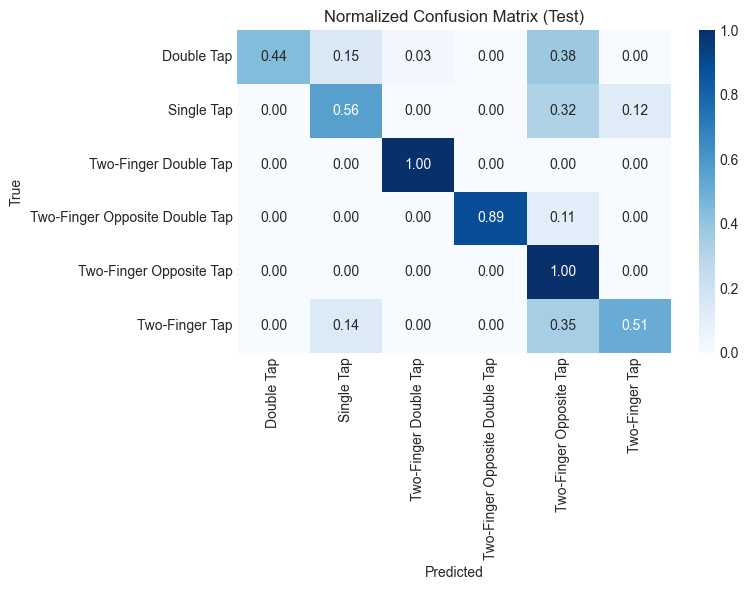

In [394]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test_win)

# print("Test classification report:\n",
#       classification_report(y_test_win, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_win, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

In [395]:
# Print which features are the most influencial for the best model if possible
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = best_model.named_steps['clf'].feature_importances_
    feature_importance_pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

    print("\nTop 50 Feature Importances:")
    for fname, importance in feature_importance_pairs[:50]:
        print(f"{fname}: {importance:.4f}")


Top 50 Feature Importances:
finger_4_touch_reactivations: 0.0813
finger_2_touch_reactivations: 0.0726
finger_3_touch_reactivations: 0.0679
finger_3_touch_starts: 0.0183
finger_2_is_continuous_touch: 0.0178
finger_2_mean_touch_duration: 0.0178
finger_2_min_touch_duration: 0.0171
finger_2_continuous_touch_duration: 0.0161
finger_3_min_time_between_reactivations: 0.0154
finger_3_touch_ends: 0.0149
finger_2_mean_touch_duration: 0.0128
finger_2_min_touch_duration: 0.0128
finger_2_touch_starts: 0.0114
finger_3_mean_time_between_reactivations_bucket_1: 0.0105
finger_2_max_touch_duration: 0.0097
finger_2_touch_ends: 0.0094
finger_2_min_touch_duration_bucket_2: 0.0093
finger_2_min_time_between_reactivations: 0.0084
finger_4_pressures_velocity_std: 0.0082
finger_distance_2_q75_bucket_4: 0.0075
finger_distance_2_mean_bucket_3: 0.0071
finger_2_mean_touch_duration_bucket_2: 0.0069
finger_2_total_touch_duration_bucket_2: 0.0068
finger_distance_2_max_bucket_3: 0.0068
finger_2_mean_touch_duration_buc

In [396]:
import re
from collections import defaultdict

# Regex patterns
PATTERNS = [
    # finger_X_yyy_bucket_Z
    re.compile(r"^finger_(?P<finger>\d+)_(?P<feature>.+?)_\d+$"),
    # finger_X_yyy
    re.compile(r"^finger_(?P<finger>\d+)_(?P<feature>.+)$"),
    # finger_distance_yyy_X_bucket_Z
    re.compile(r"^finger_distance_(?P<finger>\d+)_(?P<feature>.+?)_\d+$"),
    # finger_distance_yyy_X
    re.compile(r"^finger_distance_(?P<finger>\d+)_(?P<feature>.+?)$"),
]

PATTERN_NAMES = [
    "Finger Feature Bucket",
    "Finger Feature",
    "Finger Distance Feature Bucket",
    "Finger Distance Feature",
]


def parse_feature_name(name):
    for idx, pattern in enumerate(PATTERNS):
        match = pattern.match(name)
        if match:
            return match.groupdict(), idx
    return None, -1


def aggregate_feature_importances(feature_importance_pairs):
    """
    Aggregates by (finger, feature_name)
    Buckets and distance variants are merged.
    """
    aggregated = defaultdict(float)

    for fname, importance in feature_importance_pairs:
        parsed, pattern_idx = parse_feature_name(fname)
        if parsed is None:
            # fallback: keep original name
            aggregated[fname] += importance
            continue

        key = parsed["feature"]
        pattern_name = PATTERN_NAMES[pattern_idx]
        aggregated[pattern_name + " " + key] += importance

    return dict(aggregated)

aggregated_importances = aggregate_feature_importances(feature_importance_pairs)
# Sort aggregated importances
sorted_aggregated = sorted(aggregated_importances.items(), key=lambda x: x[1], reverse=True)
print("\nTop 50 Aggregated Feature Importances:")
for feature, importance in sorted_aggregated[:50]:
    print(f"{feature}: {importance:.4f}")


Top 50 Aggregated Feature Importances:
Finger Feature touch_reactivations: 0.2218
Finger Distance Feature Bucket q25_bucket: 0.0554
Finger Distance Feature Bucket min_bucket: 0.0479
Finger Distance Feature Bucket q75_bucket: 0.0468
Finger Distance Feature Bucket max_bucket: 0.0459
Finger Distance Feature Bucket mean_bucket: 0.0429
Finger Feature touch_starts: 0.0352
Finger Feature mean_touch_duration: 0.0319
Finger Feature min_touch_duration: 0.0315
Finger Feature touch_ends: 0.0290
Finger Feature Bucket min_touch_duration_bucket: 0.0266
Finger Feature Bucket mean_touch_duration_bucket: 0.0258
Finger Feature min_time_between_reactivations: 0.0241
Finger Feature Bucket mean_time_between_reactivations_bucket: 0.0194
Finger Feature is_continuous_touch: 0.0178
Finger Feature continuous_touch_duration: 0.0176
Finger Feature Bucket total_touch_duration_bucket: 0.0171
Finger Feature Bucket max_touch_duration_bucket: 0.0161
Finger Feature Bucket max_time_between_reactivations_bucket: 0.0153
F

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │       308,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,534 (1.34 MB)

 Trainable params: 350,534 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
47/47 - 1s - 15ms/step - accuracy: 0.6716 - loss: 0.8704 - val_accuracy: 0.7819 - val_loss: 0.7611
Epoch 2/100
47/47 - 0s - 3ms/step - accuracy: 0.8927 - loss: 0.2826 - val_accuracy: 0.8191 - val_loss: 1.0592
Epoch 3/100
47/47 - 0s - 3ms/step - accuracy: 0.9294 - loss: 0.1965 - val_accuracy: 0.8138 - val_loss: 1.0164
Epoch 4/100
47/47 - 0s - 3ms/step - accuracy: 0.9620 - loss: 0.1021 - val_accuracy: 0.7553 - val_loss: 1.3651
Epoch 5/100
47/47 - 0s - 3ms/step - accuracy: 0.9740 - loss: 0.0701 - val_accuracy: 0.8245 - val_loss: 1.3955
Epoch 6/100
47/47 - 0s - 3ms/step - accuracy: 0.9753 - loss: 0.0680 - val_accuracy: 0.7606 - val_loss: 1.4156
Epoch 7/100
47/47 - 0s - 3ms/step - accuracy: 0.9833 - loss: 0.0485 - val_accuracy: 0.8351 - val_loss: 1.4466
Epoch 8/100
47/47 - 0s - 3ms/step - accuracy: 0.9773 - loss: 0.0470 - val_accuracy: 0.8245 - val_loss: 1.4507
Epoch 9/100
47/47 - 0s - 3ms/step - accuracy: 0.9840 - loss: 0.0472 - val_accuracy: 0.8085 - val_loss: 1.5935
Epoch 10/

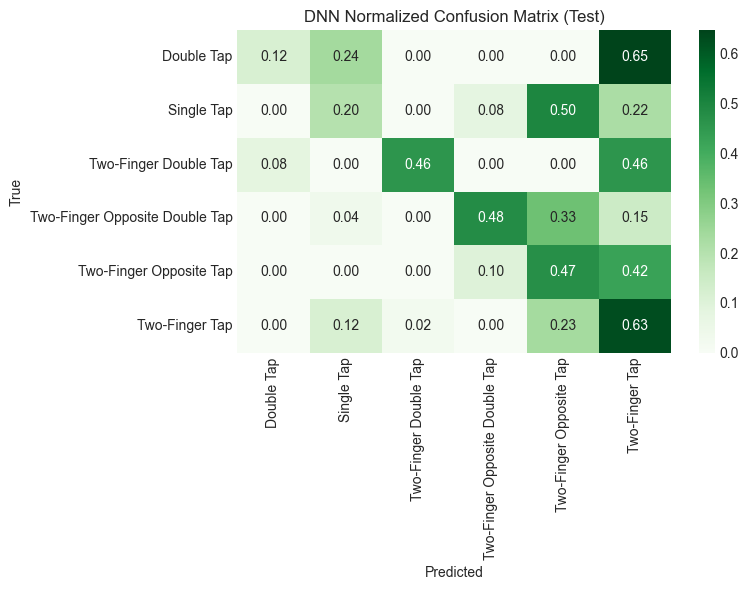

In [397]:
# Drain a DNN on the same data for comparison
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_dnn_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dnn_model = create_dnn_model(input_shape=(X_train_win.shape[1],), num_classes=len(le.classes_))
dnn_model.summary()
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history = dnn_model.fit(
    X_train_win, y_train_win,
    validation_data=(X_val_win, y_val_win),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2
)
# Evaluate on test set
test_loss, test_accuracy = dnn_model.evaluate(X_test_win, y_test_win, verbose=0)
print(f"DNN Test Accuracy: {test_accuracy:.4f}")

y_test_dnn_pred_probs = dnn_model.predict(X_test_win)
y_test_dnn_pred = np.argmax(y_test_dnn_pred_probs, axis=1)
print("DNN Test classification report:\n",
      classification_report(y_test_win, y_test_dnn_pred, target_names=le.classes_))

cm_dnn = confusion_matrix(y_test_win, y_test_dnn_pred)
cm_dnn_norm = cm_dnn.astype("float") / cm_dnn.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dnn_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DNN Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()
        

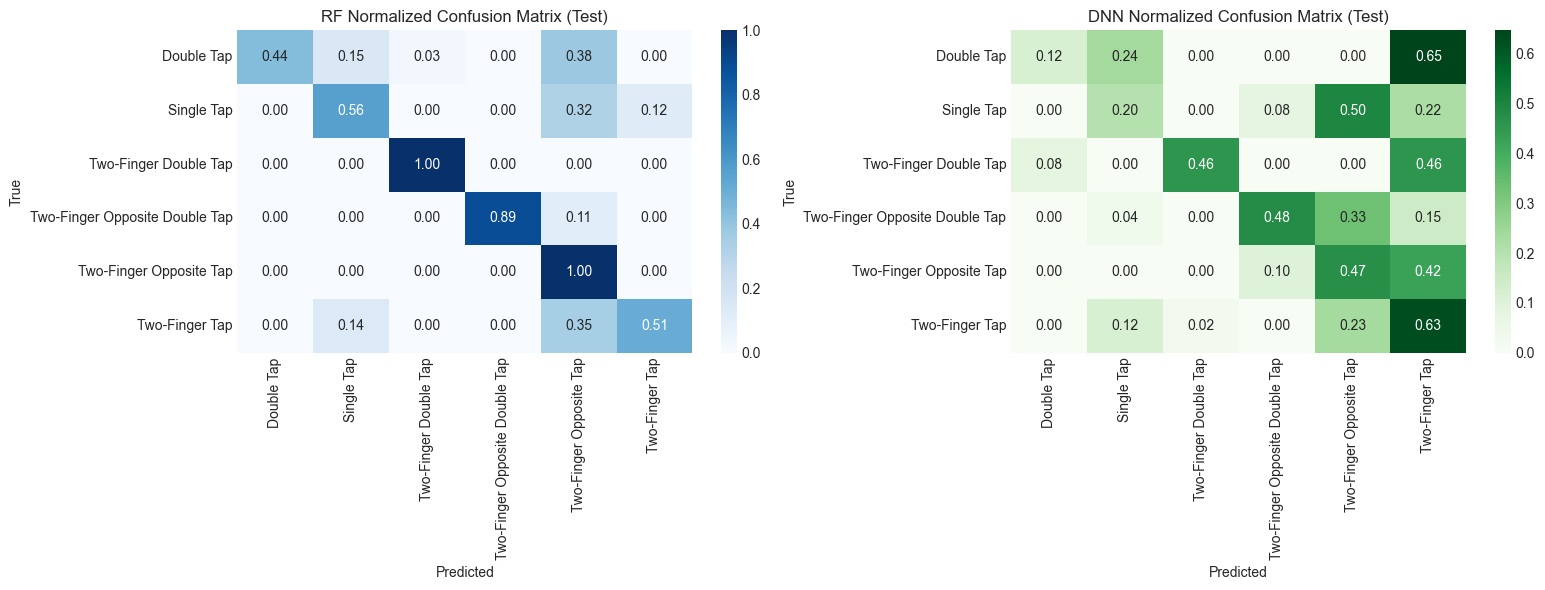

In [398]:
# compare the confusion matrixes and show a plot comparing both models
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RF Normalized Confusion Matrix (Test)")
plt.subplot(1, 2, 2)
sns.heatmap(cm_dnn_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DNN Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()